In [48]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [49]:
# ============================================================
# 2. DATA PREPARATION
# ============================================================

data = pd.read_excel('data/working_dataset.xlsx')

target = 'DEFAUT'

# ------------------------------------------------------------
# 2.1 Create variables from DATE_OPERATION
# ------------------------------------------------------------
# DATE_OPERATION can contain useful temporal information.
# We extract year, month, and day before dropping the original date.
# Machine learning models cannot directly use raw dates properly.

data['DATE_OPERATION'] = pd.to_datetime(data['DATE_OPERATION'], errors='coerce')

data['ANNEE_OPERATION'] = data['DATE_OPERATION'].dt.year
data['MOIS_OPERATION'] = data['DATE_OPERATION'].dt.month
data['JOUR_OPERATION'] = data['DATE_OPERATION'].dt.day

# Drop original date variable after extracting useful information
data = data.drop(columns=['DATE_OPERATION'], errors='ignore')


# ------------------------------------------------------------
# 2.2 Remove leakage variables
# ------------------------------------------------------------
# IMPORTANT:
# DEFAUT was created using NBIMP, so NBIMP must not be used
# as an explanatory variable.
# IMPAYE and MNTREMB are also directly related to repayment/default.
# Keeping them would create data leakage and artificially high results.

# Variables à supprimer
# NBIMP, IMPAYE, MNTREMB : variables liées directement au défaut/remboursement
# NB_ECH : supprimée car elle est très fortement corrélée avec DUREE (corr = 0.9665)

variables_to_drop = [
    'NBIMP',
    'IMPAYE',
    'MNTREMB',
    'NB_ECH'
]

data = data.drop(columns=variables_to_drop, errors='ignore')


# ------------------------------------------------------------
# 2.3 Separate X and y
# ------------------------------------------------------------

X = data.drop(columns=[target])
y = data[target]


# ------------------------------------------------------------
# 2.4 Check target distribution
# ------------------------------------------------------------

print("Shape of X:", X.shape)
print("\nDistribution of DEFAUT:")
print(y.value_counts())
print("\nDistribution of DEFAUT (%):")
print(y.value_counts(normalize=True).mul(100).round(2))

Shape of X: (25680, 16)

Distribution of DEFAUT:
DEFAUT
1    13249
0    12431
Name: count, dtype: int64

Distribution of DEFAUT (%):
DEFAUT
1    51.59
0    48.41
Name: proportion, dtype: float64


In [50]:
# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

# stratify=y keeps the same proportion of DEFAUT = 0 and DEFAUT = 1
# in both training and test sets.
# This is important for classification problems.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (20544, 16)
X_test : (5136, 16)


In [51]:
# # ============================================================
# # TIME-BASED SPLIT
# # ============================================================

# data_time = pd.read_excel('data/working_dataset.xlsx')

# data_time['DATE_OPERATION'] = pd.to_datetime(data_time['DATE_OPERATION'], errors='coerce')

# # Trier les données par date
# data_time = data_time.sort_values('DATE_OPERATION').reset_index(drop=True)

# # Créer les variables temporelles
# data_time['ANNEE_OPERATION'] = data_time['DATE_OPERATION'].dt.year
# data_time['MOIS_OPERATION'] = data_time['DATE_OPERATION'].dt.month
# data_time['JOUR_OPERATION'] = data_time['DATE_OPERATION'].dt.day

# # Supprimer les variables de fuite d'information
# data_time = data_time.drop(
#     columns=['NBIMP', 'IMPAYE', 'MNTREMB', 'NB_ECH'],
#     errors='ignore'
# )

# # Supprimer DATE_OPERATION après avoir trié et créé les variables temporelles
# data_time = data_time.drop(columns=['DATE_OPERATION'], errors='ignore')

# # Séparation X / y
# X_time = data_time.drop(columns=['DEFAUT'])
# y_time = data_time['DEFAUT']

# # Split temporel : 80% premières observations pour train, 20% dernières pour test
# cutoff = int(len(data_time) * 0.8)

# X_train = X_time.iloc[:cutoff]
# X_test = X_time.iloc[cutoff:]

# y_train = y_time.iloc[:cutoff]
# y_test = y_time.iloc[cutoff:]

# print("Train:", X_train.shape)
# print("Test :", X_test.shape)

# print("\nDistribution train:")
# print(y_train.value_counts(normalize=True).mul(100).round(2))

# print("\nDistribution test:")
# print(y_test.value_counts(normalize=True).mul(100).round(2))

In [52]:
# ============================================================
# 4. PREPROCESSING
# ============================================================

# Automatically detect numerical and categorical variables

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

print("Numerical variables:")
print(numeric_features)

print("\nCategorical variables:")
print(categorical_features)


# ------------------------------------------------------------
# 4.1 Numerical preprocessing
# ------------------------------------------------------------
# Median imputation:
# Financial variables often contain extreme values.
# The median is more robust than the mean.
#
# StandardScaler:
# Needed for logistic regression because it is sensitive to scale.
# It is not necessary for trees, but using it inside the same pipeline
# keeps the workflow clean and does not harm the tree models.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


# ------------------------------------------------------------
# 4.2 Categorical preprocessing
# ------------------------------------------------------------
# Most frequent imputation:
# Used to replace missing categorical values.
#
# OneHotEncoder:
# Converts categorical variables into numerical binary columns.
# handle_unknown='ignore' prevents errors if a new category appears in test data.

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])


# ------------------------------------------------------------
# 4.3 Full preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

Numerical variables:
['MONTANT', 'DUREE', 'TAUX_INT', 'AGE']

Categorical variables:
['INDLIB_GROUPE', 'PORTEF', 'PERIODE', 'SEX', 'A_GARANTIE', 'AGENCE_LIEU', 'ETATCIVIL', 'WILAYA_NAISSANCE', 'TYPE_CLIENT']


In [53]:
# ============================================================
# 5. DEFINE THE THREE MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        penalty='l2',          # L2 regularization helps control overfitting
        C=1.0,                 # Smaller C = stronger regularization
        max_iter=2000,
        random_state=42
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        criterion='gini',
        max_depth=6,           # Limits tree depth to reduce overfitting
        min_samples_leaf=30,   # Avoids very small terminal nodes
        ccp_alpha=0.0,         # Cost-complexity pruning parameter
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,      # Number of trees
        criterion='gini',
        max_depth=10,          # Controls overfitting
        min_samples_leaf=20,   # Avoids very small leaves
        random_state=42,
        n_jobs=-1
    )
}

In [54]:
# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Predicted probabilities for ROC-AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix on test set
    tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
    
    # Specificity = ability to correctly detect non-default clients
    specificity = tn / (tn + fp)
    
    # Train metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_auc = roc_auc_score(y_train, y_train_proba)
    
    # Test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_auc = roc_auc_score(y_test, y_test_proba)
    
    # Train-test gaps
    gap_accuracy = train_accuracy - test_accuracy
    gap_f1 = train_f1 - test_f1
    gap_auc = train_auc - test_auc
    
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    
    print("\n--- TRAIN PERFORMANCE ---")
    print("Accuracy :", round(train_accuracy, 4))
    print("Precision:", round(train_precision, 4))
    print("Recall / Sensitivity:", round(train_recall, 4))
    print("F1-score :", round(train_f1, 4))
    print("ROC-AUC  :", round(train_auc, 4))
    
    print("\n--- TEST PERFORMANCE ---")
    print("Accuracy :", round(test_accuracy, 4))
    print("Precision:", round(test_precision, 4))
    print("Recall / Sensitivity:", round(test_recall, 4))
    print("Specificity:", round(specificity, 4))
    print("F1-score :", round(test_f1, 4))
    print("ROC-AUC  :", round(test_auc, 4))
    
    print("\n--- CONFUSION MATRIX TEST ---")
    print(confusion_matrix(y_test, y_test_pred))
    print("TN:", tn, "| FP:", fp, "| FN:", fn, "| TP:", tp)
    
    print("\n--- CLASSIFICATION REPORT TEST ---")
    print(classification_report(y_test, y_test_pred))
    
    print("\n--- OVERFITTING / UNDERFITTING CHECK ---")
    print("Gap Accuracy train-test:", round(gap_accuracy, 4))
    print("Gap F1 train-test:", round(gap_f1, 4))
    print("Gap ROC-AUC train-test:", round(gap_auc, 4))
    
    if train_f1 > 0.80 and gap_f1 > 0.10:
        diagnostic = "Possible overfitting"
    elif train_f1 < 0.60 and test_f1 < 0.60:
        diagnostic = "Possible underfitting"
    else:
        diagnostic = "Acceptable generalization"
    
    print("Diagnostic:", diagnostic)
    
    return {
        "Model": model_name,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall/Sensitivity": test_recall,
        "Test Specificity": specificity,
        "Test F1-score": test_f1,
        "Test ROC-AUC": test_auc,
        "Gap Accuracy": gap_accuracy,
        "Gap F1": gap_f1,
        "Gap ROC-AUC": gap_auc,
        "Diagnostic": diagnostic
    }

In [55]:
# ============================================================
# 7. CROSS-VALIDATION FUNCTION
# ============================================================

def cross_validation_scores(model_name, model, X_train, y_train):
    
    # StratifiedKFold keeps the same class proportions in each fold.
    # This is better for classification than simple KFold.
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc'
    }
    
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )
    
    print("=" * 80)
    print("Cross-validation:", model_name)
    print("=" * 80)
    
    print("CV Accuracy :", round(cv_results['test_accuracy'].mean(), 4), "+/-", round(cv_results['test_accuracy'].std(), 4))
    print("CV Precision:", round(cv_results['test_precision'].mean(), 4), "+/-", round(cv_results['test_precision'].std(), 4))
    print("CV Recall   :", round(cv_results['test_recall'].mean(), 4), "+/-", round(cv_results['test_recall'].std(), 4))
    print("CV F1-score :", round(cv_results['test_f1'].mean(), 4), "+/-", round(cv_results['test_f1'].std(), 4))
    print("CV ROC-AUC  :", round(cv_results['test_roc_auc'].mean(), 4), "+/-", round(cv_results['test_roc_auc'].std(), 4))
    
    return {
        "Model": model_name,
        "CV Accuracy Mean": cv_results['test_accuracy'].mean(),
        "CV Accuracy Std": cv_results['test_accuracy'].std(),
        "CV Precision Mean": cv_results['test_precision'].mean(),
        "CV Precision Std": cv_results['test_precision'].std(),
        "CV Recall Mean": cv_results['test_recall'].mean(),
        "CV Recall Std": cv_results['test_recall'].std(),
        "CV F1 Mean": cv_results['test_f1'].mean(),
        "CV F1 Std": cv_results['test_f1'].std(),
        "CV ROC-AUC Mean": cv_results['test_roc_auc'].mean(),
        "CV ROC-AUC Std": cv_results['test_roc_auc'].std()
    }

In [56]:
# ============================================================
# 8. TRAIN, CROSS-VALIDATE, AND EVALUATE ALL MODELS
# ============================================================

trained_models = {}
test_results = []
cv_results_all = []

for model_name, classifier in models.items():
    
    # Full pipeline:
    # Step 1: preprocessing
    # Step 2: model training
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Cross-validation on training data only
    cv_result = cross_validation_scores(
        model_name,
        pipeline,
        X_train,
        y_train
    )
    
    cv_results_all.append(cv_result)
    
    # Fit final model on the full training set
    pipeline.fit(X_train, y_train)
    
    trained_models[model_name] = pipeline
    
    # Evaluate on train and test
    test_result = evaluate_model(
        model_name,
        pipeline,
        X_train,
        X_test,
        y_train,
        y_test
    )
    
    test_results.append(test_result)

Cross-validation: Logistic Regression
CV Accuracy : 0.8403 +/- 0.0029
CV Precision: 0.8269 +/- 0.0023
CV Recall   : 0.8733 +/- 0.0053
CV F1-score : 0.8495 +/- 0.003
CV ROC-AUC  : 0.9093 +/- 0.0024


c:\Users\delli7\Desktop\PFE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Logistic Regression

--- TRAIN PERFORMANCE ---
Accuracy : 0.841
Precision: 0.8279
Recall / Sensitivity: 0.8734
F1-score : 0.85
ROC-AUC  : 0.9107

--- TEST PERFORMANCE ---
Accuracy : 0.8446
Precision: 0.83
Recall / Sensitivity: 0.8789
Specificity: 0.8081
F1-score : 0.8537
ROC-AUC  : 0.9122

--- CONFUSION MATRIX TEST ---
[[2009  477]
 [ 321 2329]]
TN: 2009 | FP: 477 | FN: 321 | TP: 2329

--- CLASSIFICATION REPORT TEST ---
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      2486
           1       0.83      0.88      0.85      2650

    accuracy                           0.84      5136
   macro avg       0.85      0.84      0.84      5136
weighted avg       0.85      0.84      0.84      5136


--- OVERFITTING / UNDERFITTING CHECK ---
Gap Accuracy train-test: -0.0036
Gap F1 train-test: -0.0037
Gap ROC-AUC train-test: -0.0015
Diagnostic: Acceptable generalization
Cross-validation: Decision Tree
CV Accuracy : 0.839 +/- 0.0043
CV Precision: 

In [57]:
# ============================================================
# 9. FINAL COMPARISON TABLE
# ============================================================

test_results_df = pd.DataFrame(test_results)
cv_results_df = pd.DataFrame(cv_results_all)

final_results = test_results_df.merge(
    cv_results_df,
    on='Model',
    how='left'
)

final_results = final_results.sort_values(
    by='Test ROC-AUC',
    ascending=False
)

final_results.round(4)

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall/Sensitivity,Test Specificity,Test F1-score,Test ROC-AUC,Gap Accuracy,Gap F1,...,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV ROC-AUC Mean,CV ROC-AUC Std
2,Random Forest,0.8443,0.8427,0.8154,0.8985,0.7832,0.8549,0.9173,0.0016,0.0013,...,0.8423,0.0027,0.8159,0.0028,0.8966,0.0032,0.8544,0.0025,0.9129,0.0027
0,Logistic Regression,0.8410,0.8446,0.8300,0.8789,0.8081,0.8537,0.9122,-0.0036,-0.0037,...,0.8403,0.0029,0.8269,0.0023,0.8733,0.0053,0.8495,0.0030,0.9093,0.0024
1,Decision Tree,0.8442,0.8423,0.8199,0.8898,0.7916,0.8534,0.9039,0.0019,0.0010,...,0.8390,0.0043,0.8200,0.0084,0.8817,0.0044,0.8497,0.0030,0.9015,0.0021


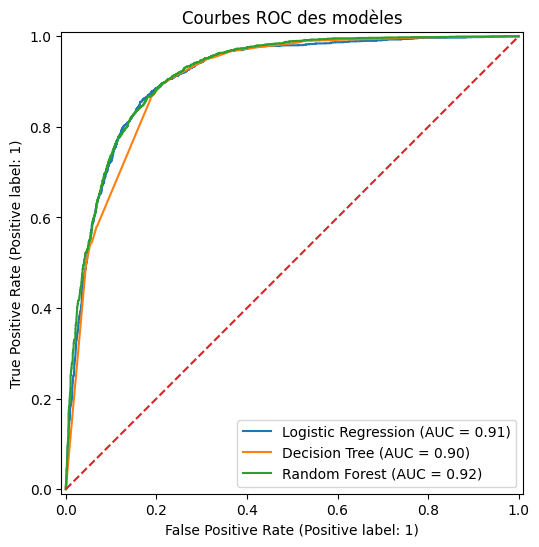

In [58]:
# ============================================================
# 11. ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

ax = plt.gca()

for model_name, model in trained_models.items():
    
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=model_name,
        ax=ax
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Courbes ROC des modèles')
plt.show()

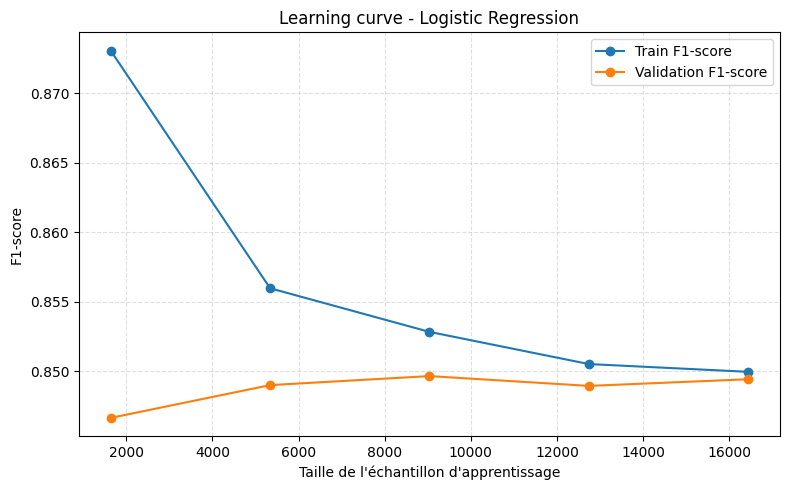

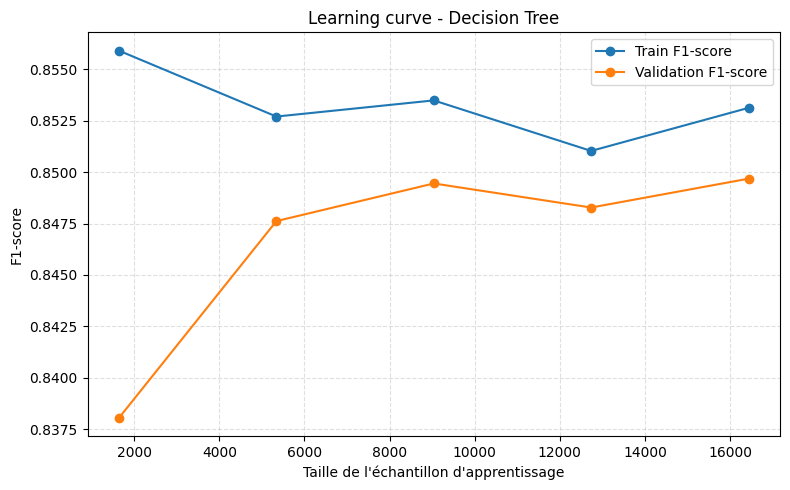

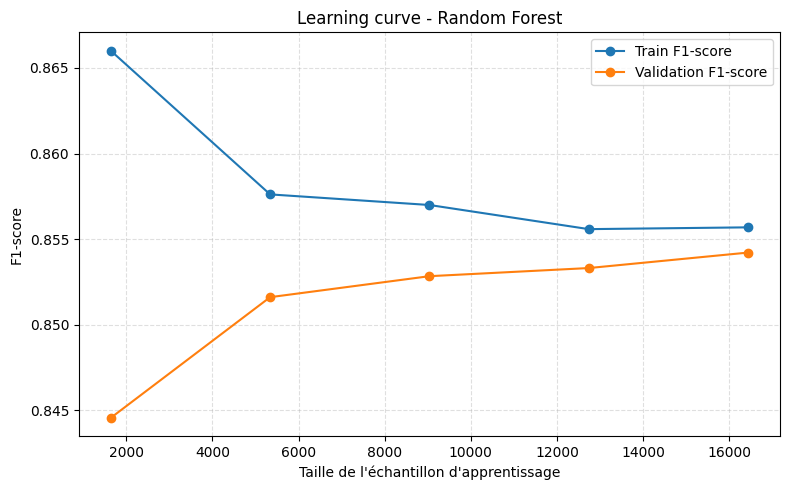

In [59]:
# ============================================================
# 12. LEARNING CURVES
# ============================================================
# Learning curves help diagnose overfitting and underfitting.
#
# If training score is high but validation score is much lower:
#    possible overfitting.
#
# If both training and validation scores are low:
#    possible underfitting.

def plot_learning_curve(model, model_name, X_train, y_train):
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(train_sizes, train_mean, marker='o', label='Train F1-score')
    plt.plot(train_sizes, val_mean, marker='o', label='Validation F1-score')
    
    plt.xlabel("Taille de l'échantillon d'apprentissage")
    plt.ylabel("F1-score")
    plt.title(f"Learning curve - {model_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


for model_name, model in trained_models.items():
    plot_learning_curve(model, model_name, X_train, y_train)

In [60]:
# ============================================================
# 13. FEATURE IMPORTANCE FOR TREE-BASED MODELS
# ============================================================
# This is not a performance metric.
# It helps interpret which variables are important for the model.

def get_feature_names_from_preprocessor(preprocessor):
    
    numeric_names = preprocessor.named_transformers_['num'].get_feature_names_out(numeric_features)
    categorical_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
    
    feature_names = np.concatenate([numeric_names, categorical_names])
    
    return feature_names


for model_name in ["Decision Tree", "Random Forest"]:
    
    model = trained_models[model_name]
    
    fitted_preprocessor = model.named_steps['preprocessor']
    classifier = model.named_steps['classifier']
    
    feature_names = get_feature_names_from_preprocessor(fitted_preprocessor)
    
    importances = classifier.feature_importances_
    
    importance_df = pd.DataFrame({
        'Variable': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print("=" * 80)
    print("Feature importance:", model_name)
    print("=" * 80)
    display(importance_df.head(15))

Feature importance: Decision Tree


,Variable,Importance
1,DUREE,0.673441
15,PORTEF_PP,0.141903
49,WILAYA_NAISSANCE_Inconnu,0.053152
28,AGENCE_LIEU_Dakhlet Nouadhibou,0.035422
5,INDLIB_GROUPE_Autres,0.017774
25,AGENCE_LIEU_Adrar,0.014787
36,AGENCE_LIEU_Tiris Zemmour,0.013024
2,TAUX_INT,0.012098
13,PORTEF_DDC,0.010625
0,MONTANT,0.009129


Feature importance: Random Forest


,Variable,Importance
1,DUREE,0.177284
19,PERIODE_S,0.122752
11,PORTEF_CAM,0.095459
15,PORTEF_PP,0.083430
18,PERIODE_M,0.079073
2,TAUX_INT,0.073867
0,MONTANT,0.067891
13,PORTEF_DDC,0.036613
34,AGENCE_LIEU_Nouakchott,0.034695
5,INDLIB_GROUPE_Autres,0.025320


In [61]:
# ============================================================
# TIME-BASED SPLIT
# ============================================================

data_time = pd.read_excel('data/working_dataset.xlsx')

data_time['DATE_OPERATION'] = pd.to_datetime(data_time['DATE_OPERATION'], errors='coerce')

# Trier les données par date
data_time = data_time.sort_values('DATE_OPERATION').reset_index(drop=True)

# Créer les variables temporelles
data_time['ANNEE_OPERATION'] = data_time['DATE_OPERATION'].dt.year
data_time['MOIS_OPERATION'] = data_time['DATE_OPERATION'].dt.month
data_time['JOUR_OPERATION'] = data_time['DATE_OPERATION'].dt.day

# Supprimer les variables de fuite d'information
data_time = data_time.drop(
    columns=['NBIMP', 'IMPAYE', 'MNTREMB', 'NB_ECH'],
    errors='ignore'
)

# Supprimer DATE_OPERATION après avoir trié et créé les variables temporelles
data_time = data_time.drop(columns=['DATE_OPERATION'], errors='ignore')

# Séparation X / y
X_time = data_time.drop(columns=['DEFAUT'])
y_time = data_time['DEFAUT']

# Split temporel : 80% premières observations pour train, 20% dernières pour test
cutoff = int(len(data_time) * 0.8)

X_train_time = X_time.iloc[:cutoff]
X_test_time = X_time.iloc[cutoff:]

y_train_time = y_time.iloc[:cutoff]
y_test_time = y_time.iloc[cutoff:]

print("Train:", X_train_time.shape)
print("Test :", X_test_time.shape)

print("\nDistribution train:")
print(y_train_time.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution test:")
print(y_test_time.value_counts(normalize=True).mul(100).round(2))

Train: (20544, 16)
Test : (5136, 16)

Distribution train:
DEFAUT
1    53.5
0    46.5
Name: proportion, dtype: float64

Distribution test:
DEFAUT
0    56.04
1    43.96
Name: proportion, dtype: float64


In [62]:
# ============================================================
# THRESHOLD OPTIMIZATION
# Example with Random Forest
# ============================================================

best_model = trained_models["Random Forest"]

y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall/Sensitivity': recall,
        'Specificity': specificity,
        'F1-score': f1,
        'FP': fp,
        'FN': fn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values('F1-score', ascending=False).head(10)

,Threshold,Accuracy,Precision,Recall/Sensitivity,Specificity,F1-score,FP,FN
37,0.47,0.841900,0.811104,0.904151,0.775543,0.855103,558,254
40,0.50,0.842679,0.815411,0.898491,0.783186,0.854937,539,269
42,0.52,0.843263,0.818873,0.893962,0.789220,0.854772,524,281
36,0.46,0.841121,0.808962,0.906038,0.771923,0.854753,567,249
34,0.44,0.839759,0.803186,0.913208,0.761464,0.854671,593,230
33,0.43,0.838785,0.799868,0.916981,0.755430,0.854430,608,220
31,0.41,0.836059,0.788449,0.932453,0.733307,0.854426,663,179
41,0.51,0.842290,0.815934,0.896604,0.784393,0.854369,536,274
43,0.53,0.843263,0.820647,0.890943,0.792438,0.854351,516,289
39,0.49,0.841706,0.813588,0.899245,0.780370,0.854275,546,267
